<a href="https://colab.research.google.com/github/JamdhadeVikrant/Code/blob/main/DSBDA4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
x=np.array([95,85,80,70,60])
y=np.array([85,95,70,65,70])

In [ ]:
model= np.polyfit(x, y, 1)
model

array([ 0.64383562, 26.78082192])

In [ ]:
predict = np.poly1d(model)
predict(65)

np.float64(68.63013698630135)

In [ ]:
y_pred= predict(x)
y_pred

array([87.94520548, 81.50684932, 78.28767123, 71.84931507, 65.4109589 ])

In [ ]:
from sklearn.metrics import r2_score
r2_score(y, y_pred)

0.4803218090889323

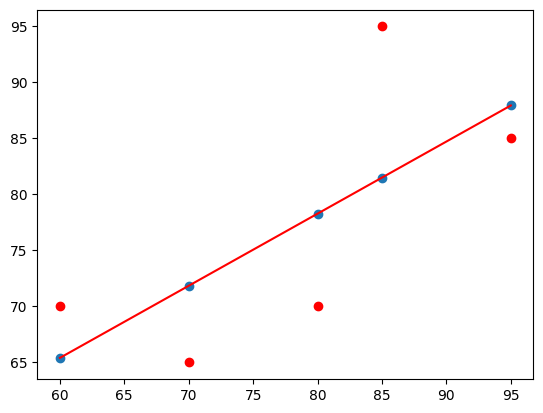

In [ ]:
y_line = model[1] + model[0]* x
plt.plot(x, y_line, c = 'r')
plt.scatter(x, y_pred)
plt.scatter(x,y,c='r')

In [ ]:
df=pd.read_csv('/content/BostonHousing.csv')
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [ ]:
data=pd.DataFrame(df)
data.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [ ]:
from sklearn.datasets import load_boston

ImportError: 
`load_boston` has been removed from scikit-learn since version 1.2.

The Boston housing prices dataset has an ethical problem: as
investigated in [1], the authors of this dataset engineered a
non-invertible variable "B" assuming that racial self-segregation had a
positive impact on house prices [2]. Furthermore the goal of the
research that led to the creation of this dataset was to study the
impact of air quality but it did not give adequate demonstration of the
validity of this assumption.

The scikit-learn maintainers therefore strongly discourage the use of
this dataset unless the purpose of the code is to study and educate
about ethical issues in data science and machine learning.

In this special case, you can fetch the dataset from the original
source::

    import pandas as pd
    import numpy as np

    data_url = "http://lib.stat.cmu.edu/datasets/boston"
    raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
    data = np.hstack([raw_df.values[:

In [ ]:
data.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'medv'],
      dtype='object')

In [ ]:
data.isnull().sum()

,0
crim,0
zn,0
indus,0
chas,0
nox,0
rm,5
age,0
dis,0
rad,0
tax,0


In [ ]:
x = data.drop(['medv'], axis=1)
y = data['medv']

In [ ]:
from sklearn.model_selection import train_test_split

xtrain, xtest, ytrain, ytest = train_test_split(
    x, y, test_size=0.2, random_state=0
)

In [ ]:
from sklearn.linear_model import LinearRegression
xtrain=xtrain.dropna()
ytrain=ytrain[xtrain.index]
lm = LinearRegression()
lm.fit(xtrain, ytrain)

LinearRegression()

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression

pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('model', LinearRegression())
])

pipeline.fit(xtrain, ytrain)
ytest_pred = pipeline.predict(xtest)

In [ ]:
xtest = xtest.fillna(xtest.mean())
xtrain = xtrain.fillna(xtrain.mean())

In [ ]:
train_df = pd.DataFrame({
    'Actual': ytrain,
    'Predicted': ytrain_pred
})

test_df = pd.DataFrame({
    'Actual': ytest,
    'Predicted': ytest_pred
})

In [ ]:
train_df.head()
test_df.head()

,Actual,Predicted
329,22.6,24.921204
371,50.0,23.768142
219,23.0,29.363811
403,8.3,12.150550
78,21.2,21.426754


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

print("Train MSE:", mean_squared_error(ytrain, ytrain_pred))
print("Test MSE:", mean_squared_error(ytest, ytest_pred))
print("R2 Score:", r2_score(ytest, ytest_pred))

Train MSE: 19.394646067943167
Test MSE: 33.4454178870614
R2 Score: 0.5892661302074418


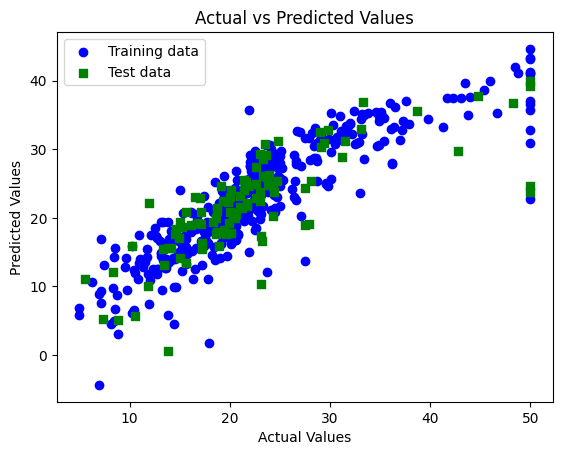

In [ ]:
plt.scatter(ytrain, ytrain_pred, c='blue', marker='o', label='Training data')
plt.scatter(ytest, ytest_pred, c='green', marker='s', label='Test data')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.legend(loc='upper left')

plt.show()

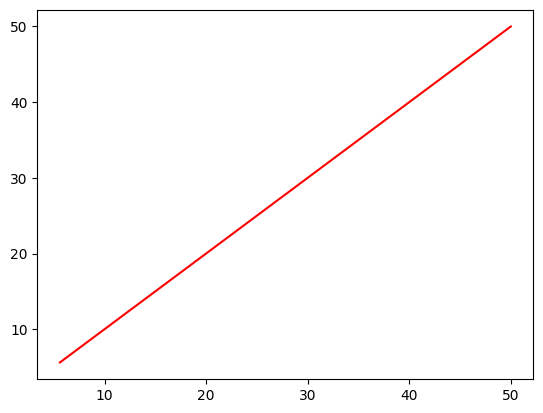

In [ ]:
plt.plot([min(ytest), max(ytest)],
         [min(ytest), max(ytest)],
         color='red')